# M1.Ex1: Model Hours vs Marks

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex1_reg.ipynb)
- Raw Dataset: [Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv)

In [1]:
import pandas as pd
import sklearn

### Step 1. Load the data

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv")
df

,Hours_Studied,Marks
0,4.76,46.27
1,3.00,34.30
2,2.08,33.63
3,4.04,47.81
4,9.49,66.26
...,...,...
95,3.20,28.66
96,9.76,70.27
97,4.54,43.99
98,9.03,65.17


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X = df[['Hours_Studied']]
y = df['Marks']

### Step 2.b print the type of each

In [4]:
# Notice the "s" plural since it is a DataFrame
X.dtypes

Hours_Studied    float64
dtype: object

In [5]:
y.dtype

dtype('float64')

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

- Target is numerical since it is a float.
- Task is regression because target is numerical.

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [6]:
X.shape

(100, 1)

In [7]:
y.shape

(100,)

### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [8]:
df.describe()

,Hours_Studied,Marks
count,100.000000,100.000000
mean,5.376300,46.360200
std,2.593013,14.284805
min,1.050000,20.190000
25%,3.175000,33.675000
50%,5.565000,47.485000
75%,7.255000,57.377500
max,9.870000,73.260000


### Step 5. Plot the feature vs the target

<Axes: xlabel='Hours_Studied', ylabel='Marks'>

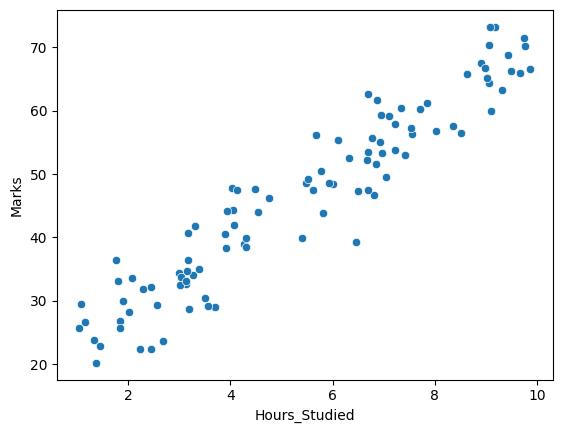

In [9]:
import seaborn as sns

sns.scatterplot(df, x='Hours_Studied', y='Marks')

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

Increasing. Because as we increase Hours Studies, we seee an increase in Marks.

### Step 7. Initialize a `LinearRegression` model

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [11]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=10,
)

### Step 9.a Train the model on the training set

In [12]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the model

In [13]:
m = model.coef_[0].round(2)
b = model.intercept_.round(2)

In [14]:
print('slope:', m)
print('intercept:', b)

slope: 5.09
intercept: 19.58


### Step 9.c how much marks do we get per 1 hour of study?

In [15]:
print("We get", m, "marks per 1 hour of study")

We get 5.09 marks per 1 hour of study


### Step 9.d how much does a 10 minutes increase of study time adds to our marks?

In [16]:
ten_minutes = 10 / 60
how_much = (ten_minutes) * m
how_much.round(2)

np.float64(0.85)

### Step 9.e if one doesn't study at all, how much marks do they get?

In [17]:
print("If one doesn't study at all, they get", b, "marks")

If one doesn't study at all, they get 19.58 marks


### Step 10. Evaluate the model on the test set

In [18]:
model.score(X_test, y_test)

0.8149405607914277

### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [19]:
# # Take a random sample of three rows from the test set
# idx = X_test.sample(3).index
# X_sample = X_test.loc[idx]
# y_sample = y_test.loc[idx]
# y_pred = model.predict(X_test.loc[idx])

In [20]:
# Take the first 9 rows
X_sample = X_test[:9]
y_sample = y_test[:9]
y_pred = model.predict(X_sample)

In [21]:
pd.DataFrame({
    'y_pred': y_pred,
    'y_true': y_sample,
})

,y_pred,y_true
19,37.432299,30.48
14,37.686597,29.19
43,35.041896,33.69
37,33.210949,23.59
66,57.877871,57.31
3,40.127859,47.81
79,32.041178,22.30
41,25.429426,26.60
38,26.548338,20.19


### Step 12. Plot the data and the regression line

In [22]:
import numpy as np

x_range = np.linspace(X.min(), X.max(), num=100)
y_pred = model.predict(x_range)

/home/halgoz/work/AthkaX/ai-pros/public/content/W3/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


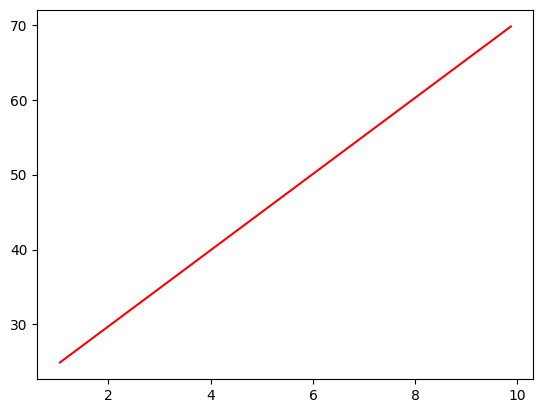

In [26]:
import matplotlib.pyplot as plt

plt.plot(x_range, y_pred, color='red')

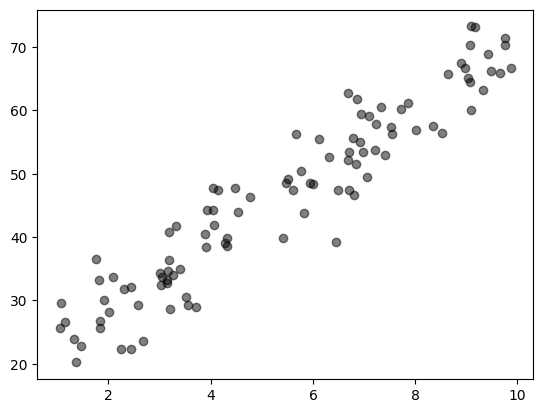

: 

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X, y, color='black', alpha=0.5)

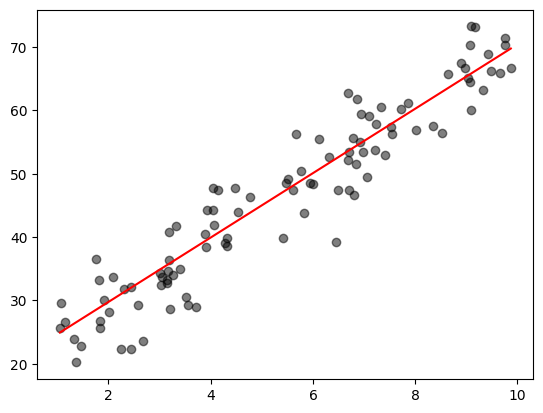

In [28]:
plt.plot(x_range, y_pred, color='red')
plt.scatter(X, y, color='black', alpha=0.5)